<a href="https://colab.research.google.com/github/PabloShol/simulacion2/blob/main/Metodo_Metroplis_Hastings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Metodo Metropolis-hastings

Ejercicio: Use el algoritmo Metroplis-Hastings para simular la función:
  $$f(x) = C e^{-\frac{x_1^2x_2^2+x_1^2+x_2^2-8x_1-8x_2}{2}}$$

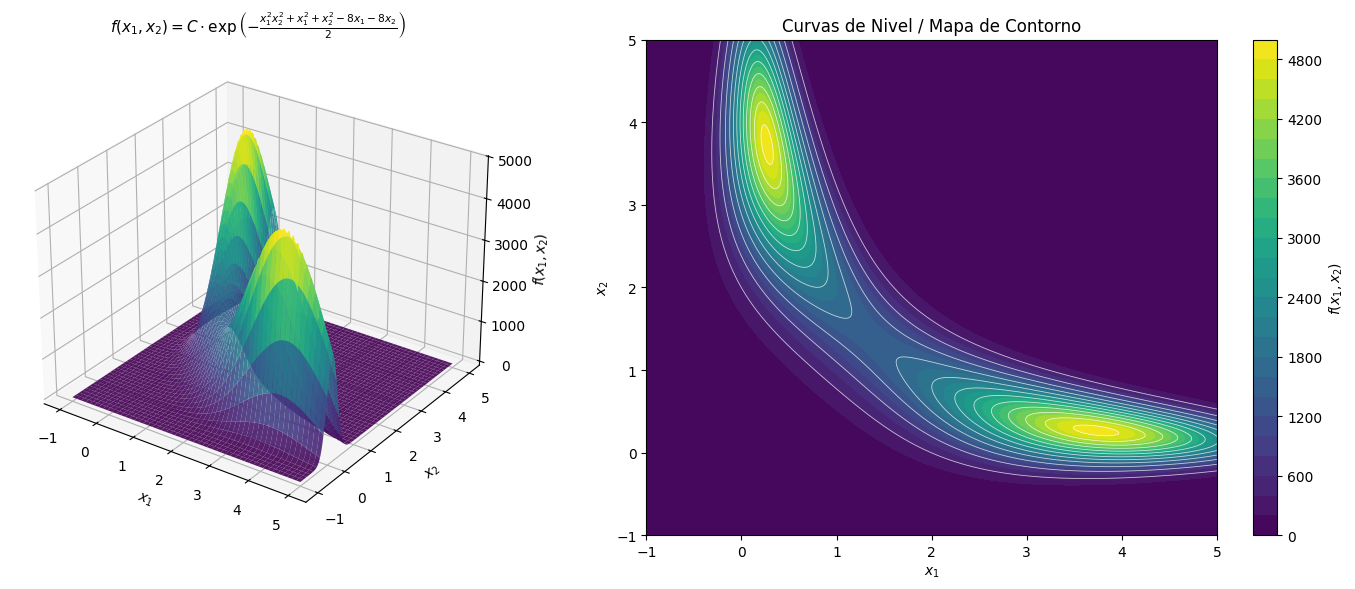

In [ ]:
# Grafica de la funcion
import numpy as np
import matplotlib.pyplot as plt

# Definir la cuadrícula en R^2
x1 = np.linspace(-1, 5, 300)
x2 = np.linspace(-1, 5, 300)
X1, X2 = np.meshgrid(x1, x2)

# Exponente: -(x1^2 * x2^2 + x1^2 + x2^2 - 8*x1 - 8*x2) / 2
exponente = -0.5 * (X1**2 * X2**2 + X1**2 + X2**2 - 8.0 * X1 - 8.0 * X2)
# Con C = 1 (forma proporcional de la función)
Z = np.exp(exponente)

# Configurar visualización (Superficie 3D y Mapa de Contornos)
fig = plt.figure(figsize=(15, 6))

# 1. Gráfica de Superficie en 3D
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(X1, X2, Z, cmap='viridis', edgecolor='none', alpha=0.9)
ax1.set_title(r'$f(x_1, x_2) = C \cdot \exp\left(-\frac{x_1^2 x_2^2 + x_1^2 + x_2^2 - 8x_1 - 8x_2}{2}\right)$', fontsize=11)
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.set_zlabel('$f(x_1, x_2)$')
ax1.view_init(elev=28, azim=-55)

# 2. Mapa de Calor y Curvas de Nivel (Contorno 2D)
ax2 = fig.add_subplot(1, 2, 2)
contour_fill = ax2.contourf(X1, X2, Z, levels=30, cmap='viridis')
ax2.contour(X1, X2, Z, levels=12, colors='white', linewidths=0.6, alpha=0.7)
cbar = fig.colorbar(contour_fill, ax=ax2)
cbar.set_label('$f(x_1, x_2)$')
ax2.set_title('Curvas de Nivel / Mapa de Contorno', fontsize=12)
ax2.set_xlabel('$x_1$')
ax2.set_ylabel('$x_2$')

plt.tight_layout()
plt.show()

# Simulacion por Metropolis-Hastings

Iteraciones totales: 60000
Período de calentamiento (burn-in): 8000
Tasa de aceptación: 38.85%


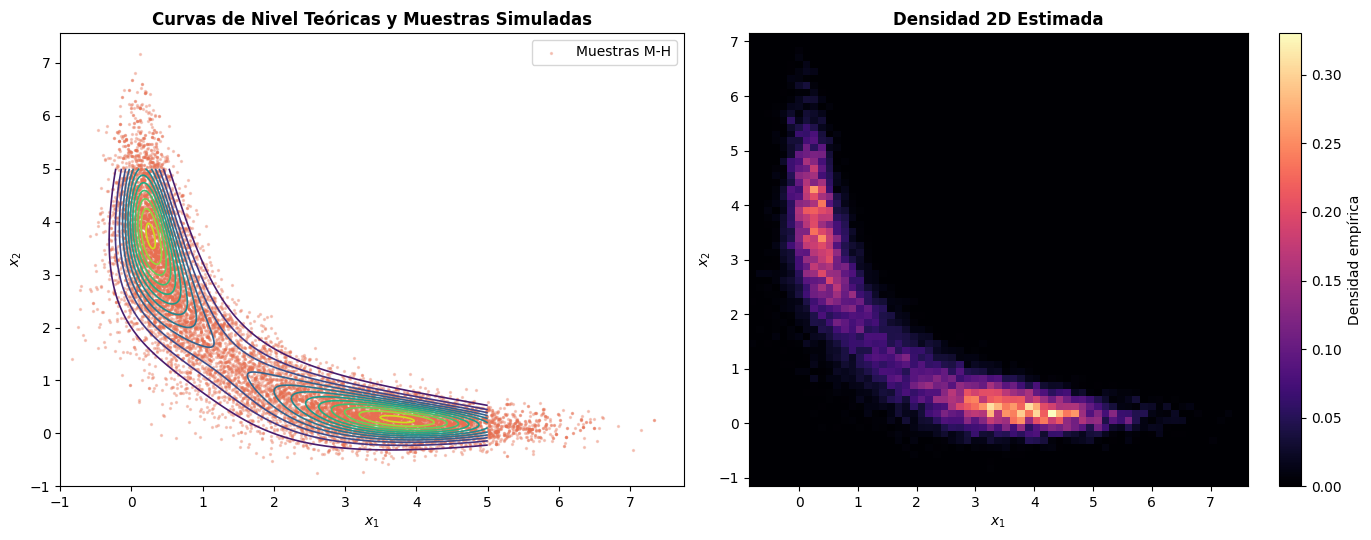

Media estimada de x1: 2.0128
Media estimada de x2: 1.7168
Varianza estimada de x1: 2.8459
Varianza estimada de x2: 2.6802


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# 1. Definición del núcleo de la densidad en escala logarítmica
# -------------------------------------------------------------
def log_f(x):
    """
    Evalúa log(f(x)) descartando la constante de normalización C.
    x: arreglo o tupla [x1, x2]
    """
    x1, x2 = x[0], x[1]
    return -0.5 * (x1**2 * x2**2 + x1**2 + x2**2 - 8.0 * x1 - 8.0 * x2)

def calcular_alpha(xt, y):
    """
    Calcula la probabilidad de aceptación alpha(X_t, Y).
    alpha = min(1, exp(log_f(Y) - log_f(X_t)))
    """
    log_diff = log_f(y) - log_f(xt)
    if log_diff >= 0.0:
        return 1.0
    return float(np.exp(log_diff))

# -------------------------------------------------------------
# 2. Algoritmo de Metropolis-Hastings (Caminata Aleatoria)
# -------------------------------------------------------------
def metropolis_hastings(n_iter=60000, sigma=0.8, x0=(0.0, 0.0), burn_in=5000):
    np.random.seed(42)
    cadena = np.empty((n_iter, 2))

    # Inicialización X_0
    cadena[0] = np.array(x0)
    aceptados = 0

    for t in range(n_iter - 1):
        # Generar candidato Y ~ N(X_t, sigma^2 * I)
        z = np.random.normal(loc=0.0, scale=sigma, size=2)
        y = cadena[t] + z

        # Evaluar aceptación
        alpha = calcular_alpha(cadena[t], y)
        u = np.random.uniform(0.0, 1.0)

        if u < alpha:
            cadena[t + 1] = y
            aceptados += 1
        else:
            cadena[t + 1] = cadena[t]

    tasa_aceptacion = (aceptados / (n_iter - 1)) * 100
    print(f"Iteraciones totales: {n_iter}")
    print(f"Período de calentamiento (burn-in): {burn_in}")
    print(f"Tasa de aceptación: {tasa_aceptacion:.2f}%")

    return cadena[burn_in:]

# Ejecución
muestras = metropolis_hastings(n_iter=60000, sigma=0.75, x0=(1.0, 1.0), burn_in=8000)

# -------------------------------------------------------------
# 3. Gráficas de Resultados (Teórica vs Simulada)
# -------------------------------------------------------------
x1_grid = np.linspace(-1, 5, 250)
x2_grid = np.linspace(-1, 5, 250)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
Z_teorica = np.exp(-0.5 * (X1**2 * X2**2 + X1**2 + X2**2 - 8.0 * X1 - 8.0 * X2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Gráfica 1: Contornos de f(x) y muestras de la cadena
axes[0].contour(X1, X2, Z_teorica, levels=14, cmap='viridis', linewidths=1.2)
axes[0].scatter(muestras[::4, 0], muestras[::4, 1], s=2, color='#e76f51', alpha=0.3, label='Muestras M-H')
axes[0].set_title('Curvas de Nivel Teóricas y Muestras Simuladas', fontsize=12, fontweight='bold')
axes[0].set_xlabel('$x_1$')
axes[0].set_ylabel('$x_2$')
axes[0].legend(loc='upper right')

# Gráfica 2: Histograma 2D (Densidad estimada empíricamente)
h = axes[1].hist2d(muestras[:, 0], muestras[:, 1], bins=65, cmap='magma', density=True)
fig.colorbar(h[3], ax=axes[1], label='Densidad empírica')
axes[1].set_title('Densidad 2D Estimada', fontsize=12, fontweight='bold')
axes[1].set_xlabel('$x_1$')
axes[1].set_ylabel('$x_2$')

plt.tight_layout()
plt.show()

# Estadísticos muestrales
print(f"Media estimada de x1: {muestras[:, 0].mean():.4f}")
print(f"Media estimada de x2: {muestras[:, 1].mean():.4f}")
print(f"Varianza estimada de x1: {muestras[:, 0].var():.4f}")
print(f"Varianza estimada de x2: {muestras[:, 1].var():.4f}")
